# MNIST Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the **MNIST handwritten digit dataset**.

MNIST contains **70,000 grayscale images of digits (0–9)**. Each image is **28×28 pixels**.

Dataset split:
- Training set: 60,000 images
- Test set: 10,000 images

Goals of this notebook:
1. Load the dataset
2. Understand its structure
3. Visualize sample digits
4. Analyze pixel distributions
5. Check label distribution
6. Normalize image data
7. Explore summary statistics


## 1. Import Required Libraries

We import the libraries required for data analysis and visualization.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2026-03-15 19:07:22.456438: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:07:22.670204: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 19:07:22.670223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 19:07:22.704776: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 19:07:22.778931: I tensorflow/core/platform/cpu_feature_guar

## 2. Load MNIST Dataset

TensorFlow provides the MNIST dataset directly through `keras.datasets`.

The dataset returns:
- `X_train` → training images
- `y_train` → training labels
- `X_test` → test images
- `y_test` → test labels

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Training images shape:', X_train.shape)
print('Training labels shape:', y_train.shape)
print('Test images shape:', X_test.shape)
print('Test labels shape:', y_test.shape)

11490434/11490434 [==============================] - 3s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


## 3. Inspect Data Types

Images are stored as **NumPy arrays**.

Each image contains pixel values ranging from **0 to 255**, representing grayscale intensity.

In [3]:
type(X_train), X_train.dtype

(numpy.ndarray, dtype('uint8'))

## 4. Visualize a Sample Digit

Let's visualize the first image in the dataset.

This will help us understand how the digit images look.

(-0.5, 27.5, 27.5, -0.5)

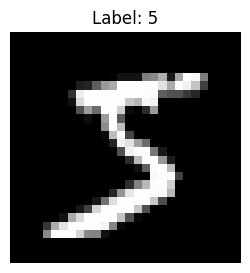

In [4]:
plt.figure(figsize=(3,3))
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.axis('off')

## 5. Display Multiple Digits

Let's display the first **10 digits** in the dataset to see different handwritten styles.

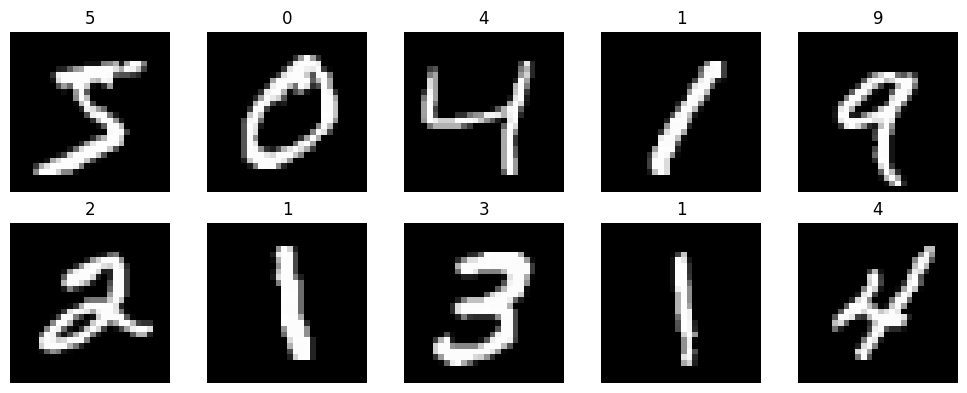

In [5]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()

## 6. Pixel Value Distribution

Pixel values represent brightness.

- 0 → black
- 255 → white

We flatten the images and inspect the distribution.

Text(0, 0.5, 'Frequency')

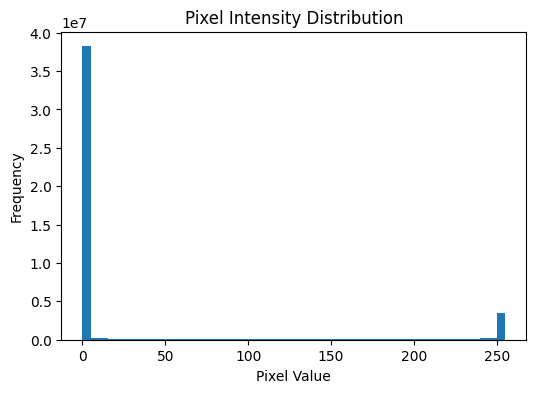

In [6]:
plt.figure(figsize=(6,4))
plt.hist(X_train.flatten(), bins=50)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

## 7. Label Distribution

We check if the dataset is balanced across digits.

Text(0.5, 1.0, 'Digit Distribution in Training Data')

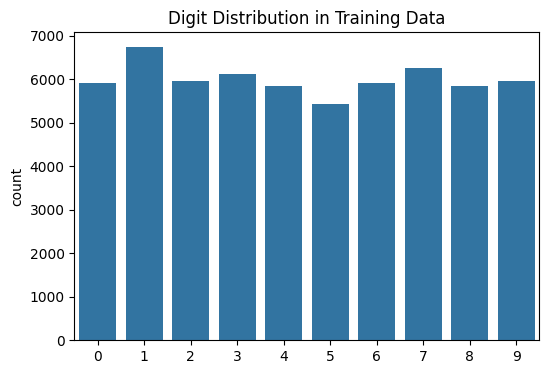

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title('Digit Distribution in Training Data')

## 8. Normalize Pixel Values

Deep learning models perform better when inputs are normalized.

We convert pixel values from:

**0–255 → 0–1**

In [8]:
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print('Max value after normalization:', np.max(X_train_norm[0]))

Max value after normalization: 1.0


## 9. Visualize Normalized Image

(-0.5, 27.5, 27.5, -0.5)

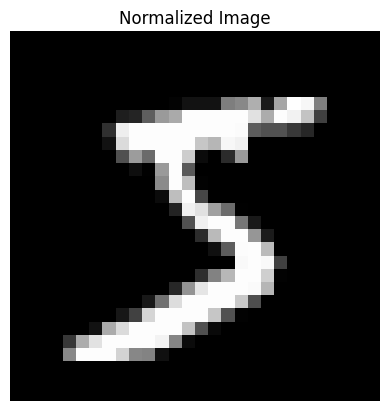

In [9]:
plt.imshow(X_train_norm[0], cmap='gray')
plt.title('Normalized Image')
plt.axis('off')

## 10. Average Digit Visualization

We compute the **average image across the dataset**.

This shows the general structure of handwritten digits.

(-0.5, 27.5, 27.5, -0.5)

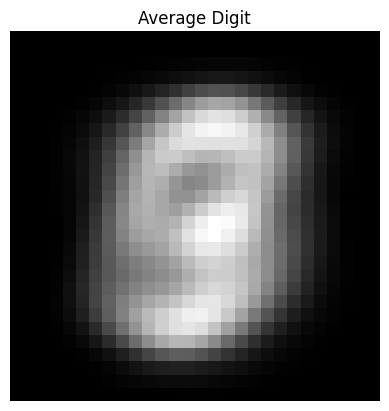

In [10]:
mean_image = np.mean(X_train_norm, axis=0)

plt.imshow(mean_image, cmap='gray')
plt.title('Average Digit')
plt.axis('off')

## 11. Dataset Summary Statistics

In [11]:
df_summary = pd.DataFrame({
    'pixel_mean':[X_train.mean()],
    'pixel_std':[X_train.std()],
    'pixel_min':[X_train.min()],
    'pixel_max':[X_train.max()]
})

df_summary

,pixel_mean,pixel_std,pixel_min,pixel_max
0,33.318421,78.56749,0,255


# Conclusion

From this exploratory analysis we learned:

- MNIST contains grayscale images of size **28×28**.
- Pixel values range from **0–255**.
- The dataset is **fairly balanced across digits**.
- Normalization improves neural network training.

Next step: **Train a neural network model using this dataset.**

# Complete basic flow

In [12]:
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Training images shape:', X_train.shape)
print('Training labels shape:', y_train.shape)
print('Test images shape:', X_test.shape)
print('Test labels shape:', y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

print(X_train.shape)

(60000, 784)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    
    Dense(128, activation='relu', input_shape=(784,)),
    
    Dense(64, activation='relu'),
    
    Dense(10, activation='softmax')
])

2026-03-15 19:08:19.357256: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-15 19:08:19.485773: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-15 19:08:19.488257: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10


2026-03-15 19:08:39.290369: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ebad833a6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-15 19:08:39.290380: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-03-15 19:08:39.300807: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-15 19:08:39.327139: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8900
I0000 00:00:1773601719.394029  198014 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 [==============================] - 3s 1ms/step - loss: 0.2680 - accuracy: 0.9215 - val_loss: 0.1466 - val_accuracy: 0.9581
Epoch 2/10
1500/1500 [==============================] - 2s 1ms/step - loss: 0.1105 - accuracy: 0.9659 - val_loss: 0.1094 - val_accuracy: 0.9674
Epoch 3/10
1500/1500 [==============================] - 1s 994us/step - loss: 0.0770 - accuracy: 0.9767 - val_loss: 0.0959 - val_accuracy: 0.9703
Epoch 4/10
1500/1500 [==============================] - 2s 1ms/step - loss: 0.0582 - accuracy: 0.9816 - val_loss: 0.0898 - val_accuracy: 0.9728
Epoch 5/10
1500/1500 [==============================] - 1s 992us/step - loss: 0.0439 - accuracy: 0.9858 - val_loss: 0.0913 - val_accuracy: 0.9743
Epoch 6/10
1500/1500 [==============================] - 2s 1ms/step - loss: 0.0374 - accuracy: 0.9875 - val_loss: 0.1021 - val_accuracy: 0.9733
Epoch 7/10
1500/1500 [==============================] - 1s 988us/step - loss: 0.0293 - accuracy: 0.9902 - val_loss: 0.1003 - val_accuracy: 0.97

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 [==============================] - 0s 632us/step - loss: 0.1072 - accuracy: 0.9750
Test Accuracy: 0.9750000238418579


In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [20]:
predictions = model.predict(X_test)

import numpy as np
predicted_label = np.argmax(predictions[0])

print("Predicted:", predicted_label)
print("Actual:", y_test[0])

313/313 [==============================] - 0s 508us/step
Predicted: 7
Actual: 7


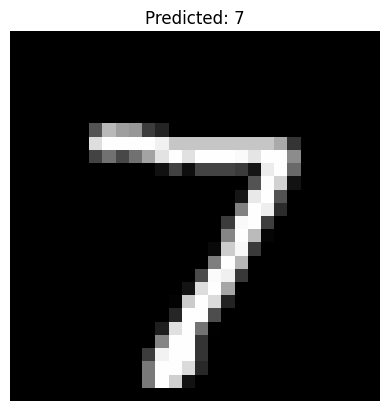

In [21]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()

In [22]:
import numpy as np

y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 [==============================] - 0s 526us/step


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.99      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.99      0.96      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.98      0.97      0.98     10000



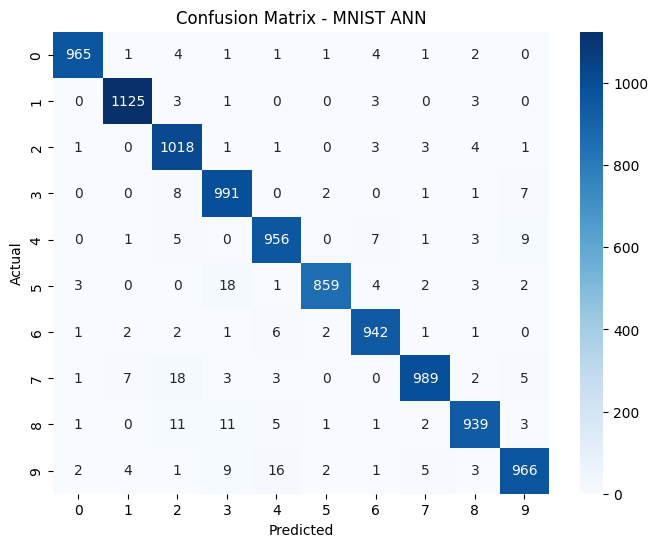

: 

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MNIST ANN")
plt.show()